### Implementing simple LangGraph Chatbot

In [5]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages] # returns a list of messages being stored

In [7]:
import os 
from dotenv import load_dotenv

load_dotenv()

groq_key = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")

groq_key

'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'

In [8]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")
llm.invoke("What is India's capital? What is the AQI?")

AIMessage(content="India's capital is New Delhi. \n\nThe current Air Quality Index (AQI) in New Delhi might be different as it varies constantly due to weather and pollution conditions. However, for a general idea, please note that in the past, New Delhi has struggled with severe air pollution issues due to pollution and emissions from vehicles, industrial sites, and crop burning.\n\nTo get the most up-to-date information on the current AQI in New Delhi, please check a reliable AQI monitoring website or mobile app such as AirNow, AirVisual, or the Indian Ministry of Earth Sciences' SAFAR website. \n\nFor example, as of my cut-off date (01 March 2023), the AQI in New Delhi was:\n\n- PM 2.5: around 100-150 (moderate pollution level)\n- PM 10: around 150-200 (moderate to poor pollution level)\n\nHowever, please note that the AQI can change significantly over time, and it is essential to check the current AQI for the most accurate information.", additional_kwargs={}, response_metadata={'to

### Start creating Nodes


In [9]:
def superbot(state: State):
    return {
        "messages": [
            llm.invoke(state["messages"])
        ]
    }

### Graph Contstruction

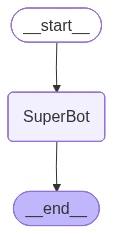

In [10]:
graph = StateGraph(State)

# Adding graph Nodes
graph.add_node("SuperBot", superbot) 
# Adding graph Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile()


# Visualizing the Graph
from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [11]:
# Invocation
graph_builder.invoke({
    "messages": "Hello i'm Anurag, and i'm a Software Engineer."
})

{'messages': [HumanMessage(content="Hello i'm Anurag, and i'm a Software Engineer.", additional_kwargs={}, response_metadata={}, id='95bd708c-2fc0-41ad-bc8d-e816b85b16b3'),
  AIMessage(content="Nice to meet you, Anurag. It's great to hear that you're a software engineer. What kind of projects or technologies are you currently working on or interested in? Are you looking for any specific help, advice, or just want to discuss the latest trends in the field? I'm all ears!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 49, 'total_tokens': 113, 'completion_time': 0.092492542, 'completion_tokens_details': None, 'prompt_time': 0.002774431, 'prompt_tokens_details': None, 'queue_time': 0.156147959, 'total_time': 0.095266973}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc246-1e91-7b00-bc30-1b6e905

In [12]:
graph_builder.invoke({
    "messages": "Do you remeber my name?"
})

{'messages': [HumanMessage(content='Do you remeber my name?', additional_kwargs={}, response_metadata={}, id='c28fd583-6b45-48c8-8a91-2ec4625e20e2'),
  AIMessage(content="I'm afraid I don't have any information about our previous conversations or your name. I'm a large language model, I don't have personal memories or the ability to retain information about individual users. Each time you interact with me, it's a new conversation and I don't retain any context from previous chats. If you'd like to share your name, I'd be happy to learn it!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 43, 'total_tokens': 124, 'completion_time': 0.232988982, 'completion_tokens_details': None, 'prompt_time': 0.003229437, 'prompt_tokens_details': None, 'queue_time': 0.046877751, 'total_time': 0.236218419}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None

In [15]:
# Streaming the messages
for event in graph_builder.stream({
    "messages": "Hello i'm Anurag"
}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content="Hello i'm Anurag", additional_kwargs={}, response_metadata={}, id='24ba2d55-0fcd-47ac-85ad-8e7dd7dd9db5')]}
{'messages': [HumanMessage(content="Hello i'm Anurag", additional_kwargs={}, response_metadata={}, id='24ba2d55-0fcd-47ac-85ad-8e7dd7dd9db5'), AIMessage(content="Hello Anurag, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 41, 'total_tokens': 69, 'completion_time': 0.029327863, 'completion_tokens_details': None, 'prompt_time': 0.001965969, 'prompt_tokens_details': None, 'queue_time': 0.044953271, 'total_time': 0.031293832}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc263-cec8-7b01-937d-7cbcb5beca11-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'i

In [16]:
for event in graph_builder.stream({
    "messages": "What is my name?"
}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='b526c94d-18d6-453d-b1fe-f348e3d0e7d0')]}
{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='b526c94d-18d6-453d-b1fe-f348e3d0e7d0'), AIMessage(content="I don't have any information about your name. I'm a conversational AI, and our conversation has just started. I don't retain any information about individual users or their identities. If you'd like to share your name with me, I can use it in our conversation.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 40, 'total_tokens': 97, 'completion_time': 0.063699278, 'completion_tokens_details': None, 'prompt_time': 0.001878951, 'prompt_tokens_details': None, 'queue_time': 0.046195139, 'total_time': 0.065578229}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'sto